# IMAU-FDM Gridded Output Visualization

This notebook provides tools for visualizing the gridded output from the IMAU-FDM 1D to maps post-processing.

**Features:**
- Load and inspect processed netCDF files
- Plot spatial maps at specific times (using xarray's native plotting)
- Plot time series at specific locations
- Calculate and visualize annual/seasonal means
- Compare multiple variables side-by-side
- Classify and visualize ice sheet facies (ablation, percolation, dry snow zones)
- Create animated GIFs of variables over time
- Plot masked differences between variables (e.g., melt vs runoff)

All visualization functions are defined in `visualization.py` and imported here.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Import local modules
import sys
sys.path.insert(0, '.')
import config
from visualization import (
    load_gridded_data,
    plot_map,
    plot_timeseries,
    plot_annual_mean,
    plot_multi_var_map,
    classify_zones,
    plot_zones,
    plot_zones_timeseries,
    print_stats,
    export_annual_means,
    create_animation_gif,
    plot_masked_difference,
    plot_process_comparison,
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

from matplotlib.colors import LinearSegmentedColormap as LSC

gr_div_cmap = LSC.from_list("gr_cmap",["#5f054d","#e26ecb", "#fffdf5","#5178ae","#1d2d44"])
gr_cmap = LSC.from_list("gr_cmap",["#fffdf5","#5178ae","#1d2d44"])


ModuleNotFoundError: No module named 'config'

## Configuration

In [8]:
# Path to gridded output files
OUTPUT_DIR = config.OUTPUT_DIR
print(f"Output directory: {OUTPUT_DIR}")

# List available files
print("\nAvailable gridded files:")
if OUTPUT_DIR.exists():
    for f in sorted(OUTPUT_DIR.glob('*.nc')):
        print(f"  {f.name}")
else:
    print(f"  Directory not found: {OUTPUT_DIR}")
    print("  Run make_1d_maps.py first to create the gridded files.")

Output directory: /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process

Available gridded files:
  FDM_FirnAir_FGRN055_1939-2023_10day_detrended.nc
  FDM_Rho0_FGRN055_1939-2023_10day.nc
  FDM_Runoff_FGRN055_1939-2023_10day.nc
  FDM_T10m_FGRN055_1939-2023_2Ddetail.nc
  FDM_TotLwc_FGRN055_1939-2023_10day.nc
  FDM_h_surf_FGRN055_1939-2023_10day_detrended.nc
  FDM_icemass_FGRN055_1939-2023_10day.nc
  FDM_rain_FGRN055_1939-2023_10day.nc
  FDM_refreeze_FGRN055_1939-2023_10day.nc
  FDM_solin_FGRN055_1939-2023_10day.nc
  FDM_surfmelt_FGRN055_1939-2023_10day.nc
  FDM_vacc_FGRN055_1939-2023_10day.nc
  FDM_vbouy_FGRN055_1939-2023_10day.nc
  FDM_vfc_FGRN055_1939-2023_10day.nc
  FDM_vice_FGRN055_1939-2023_10day.nc
  FDM_vmelt_FGRN055_1939-2023_10day.nc
  FDM_vsnd_FGRN055_1939-2023_10day.nc
  FDM_vsub_FGRN055_1939-2023_10day.nc
  FDM_vtotal_FGRN055_1939-2023_10day.nc
  FDM_z550_FGRN055_1939-2023_2D.nc
  FDM_z830_FGRN055_1939-2023_2D.nc


## Load Data

In [4]:
# Example: Load h_surf data
# Uncomment and modify as needed:

ds = load_gridded_data('h_surf', timestep='10day')

# print(ds)

Loading: FDM_h_surf_FGRN055_1939-2023_10day_detrended.nc


## Example Visualizations

Uncomment and run the cells below after generating the gridded data.

Loading: FDM_Runoff_FGRN055_1939-2023_10day.nc
Loading: FDM_surfmelt_FGRN055_1939-2023_10day.nc
Loading: FDM_refreeze_FGRN055_1939-2023_10day.nc


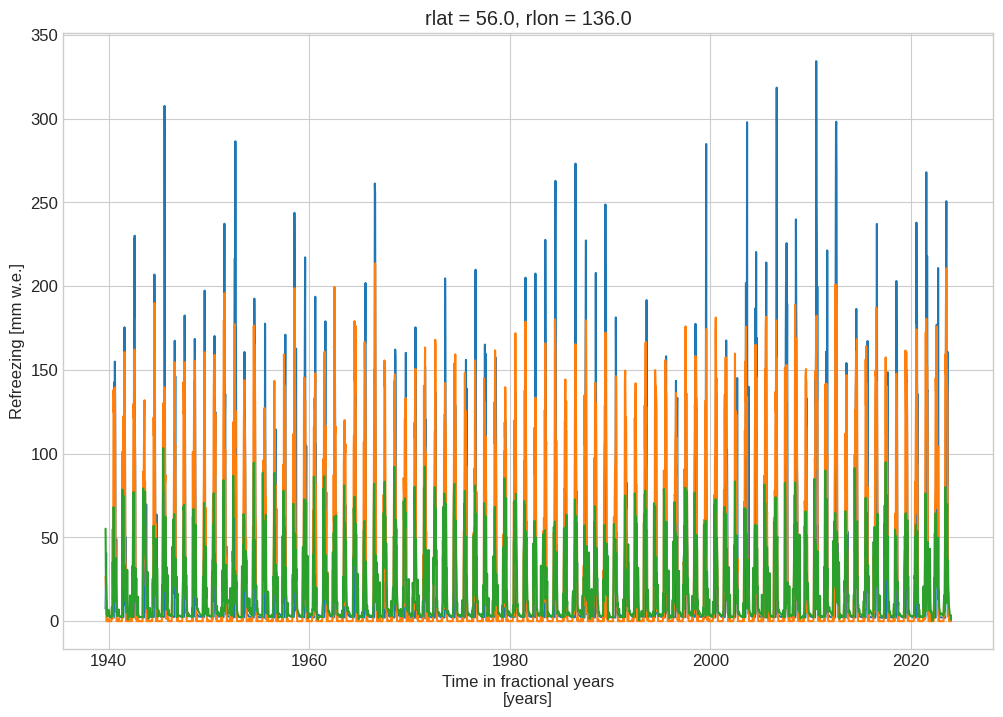

In [5]:
# Example 3: Plot time series at Summit (approx. -38.5°, 72.5°)
ds_r = load_gridded_data('Runoff')
ds_s = load_gridded_data('surfmelt')
ds_f = load_gridded_data('refreeze')
# plot_timeseries(ds, 'h_surf', lon_point=-38.5, lat_point=72.5)
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(1,1)
ds_r.Runoff.isel(rlat=56,rlon=136).plot(ax=ax)
ds_s.surfmelt.isel(rlat=56,rlon=136).plot(ax=ax)
ds_f.refreeze.isel(rlat=56,rlon=136).plot(ax=ax)


Loading: FDM_FirnAir_FGRN055_1939-2023_10day_detrended.nc
Loading: FDM_surfmelt_FGRN055_1939-2023_10day.nc
Loading: FDM_Runoff_FGRN055_1939-2023_10day.nc


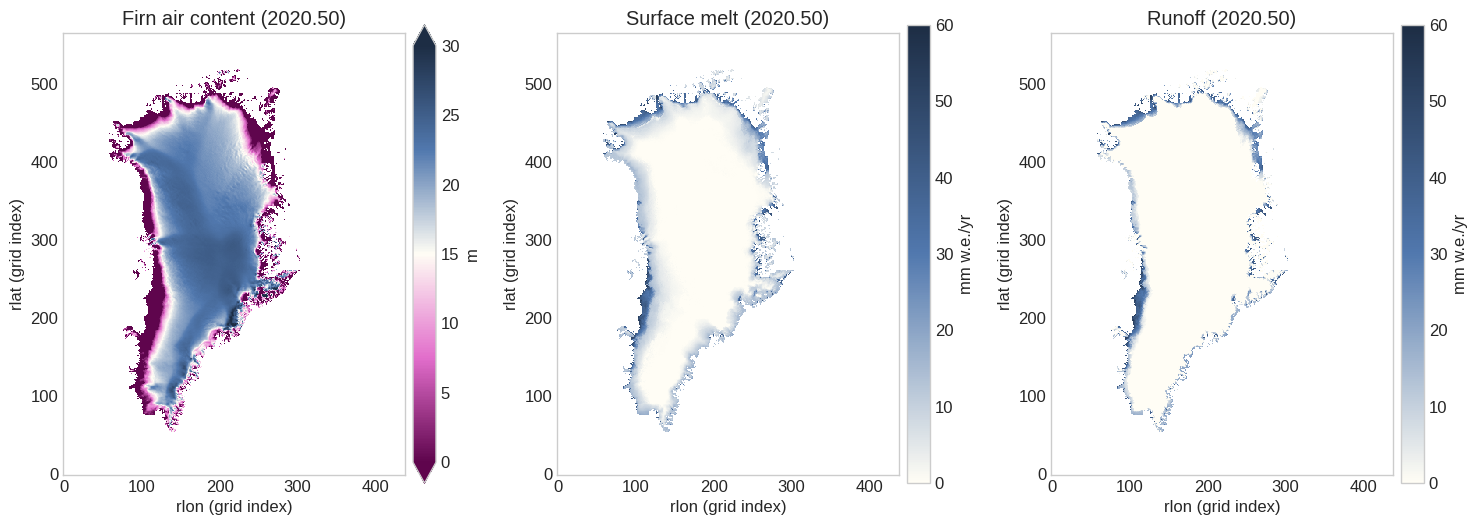

In [15]:
# Example 6: Plot three variables side by side at the same time
plot_multi_var_map(
    ['FirnAir', 'surfmelt', 'Runoff'],
    time_value=2020.5,
    cmaps=[gr_div_cmap, gr_cmap, gr_cmap],
    vlims=[(0,30), (0, 60), (0, 60)]
)
plt.show()

In [ ]:
# Example 7: Plot ice sheet facies zones for a single year
plot_zones(2020, firn_air_threshold=0.5)
plt.show()

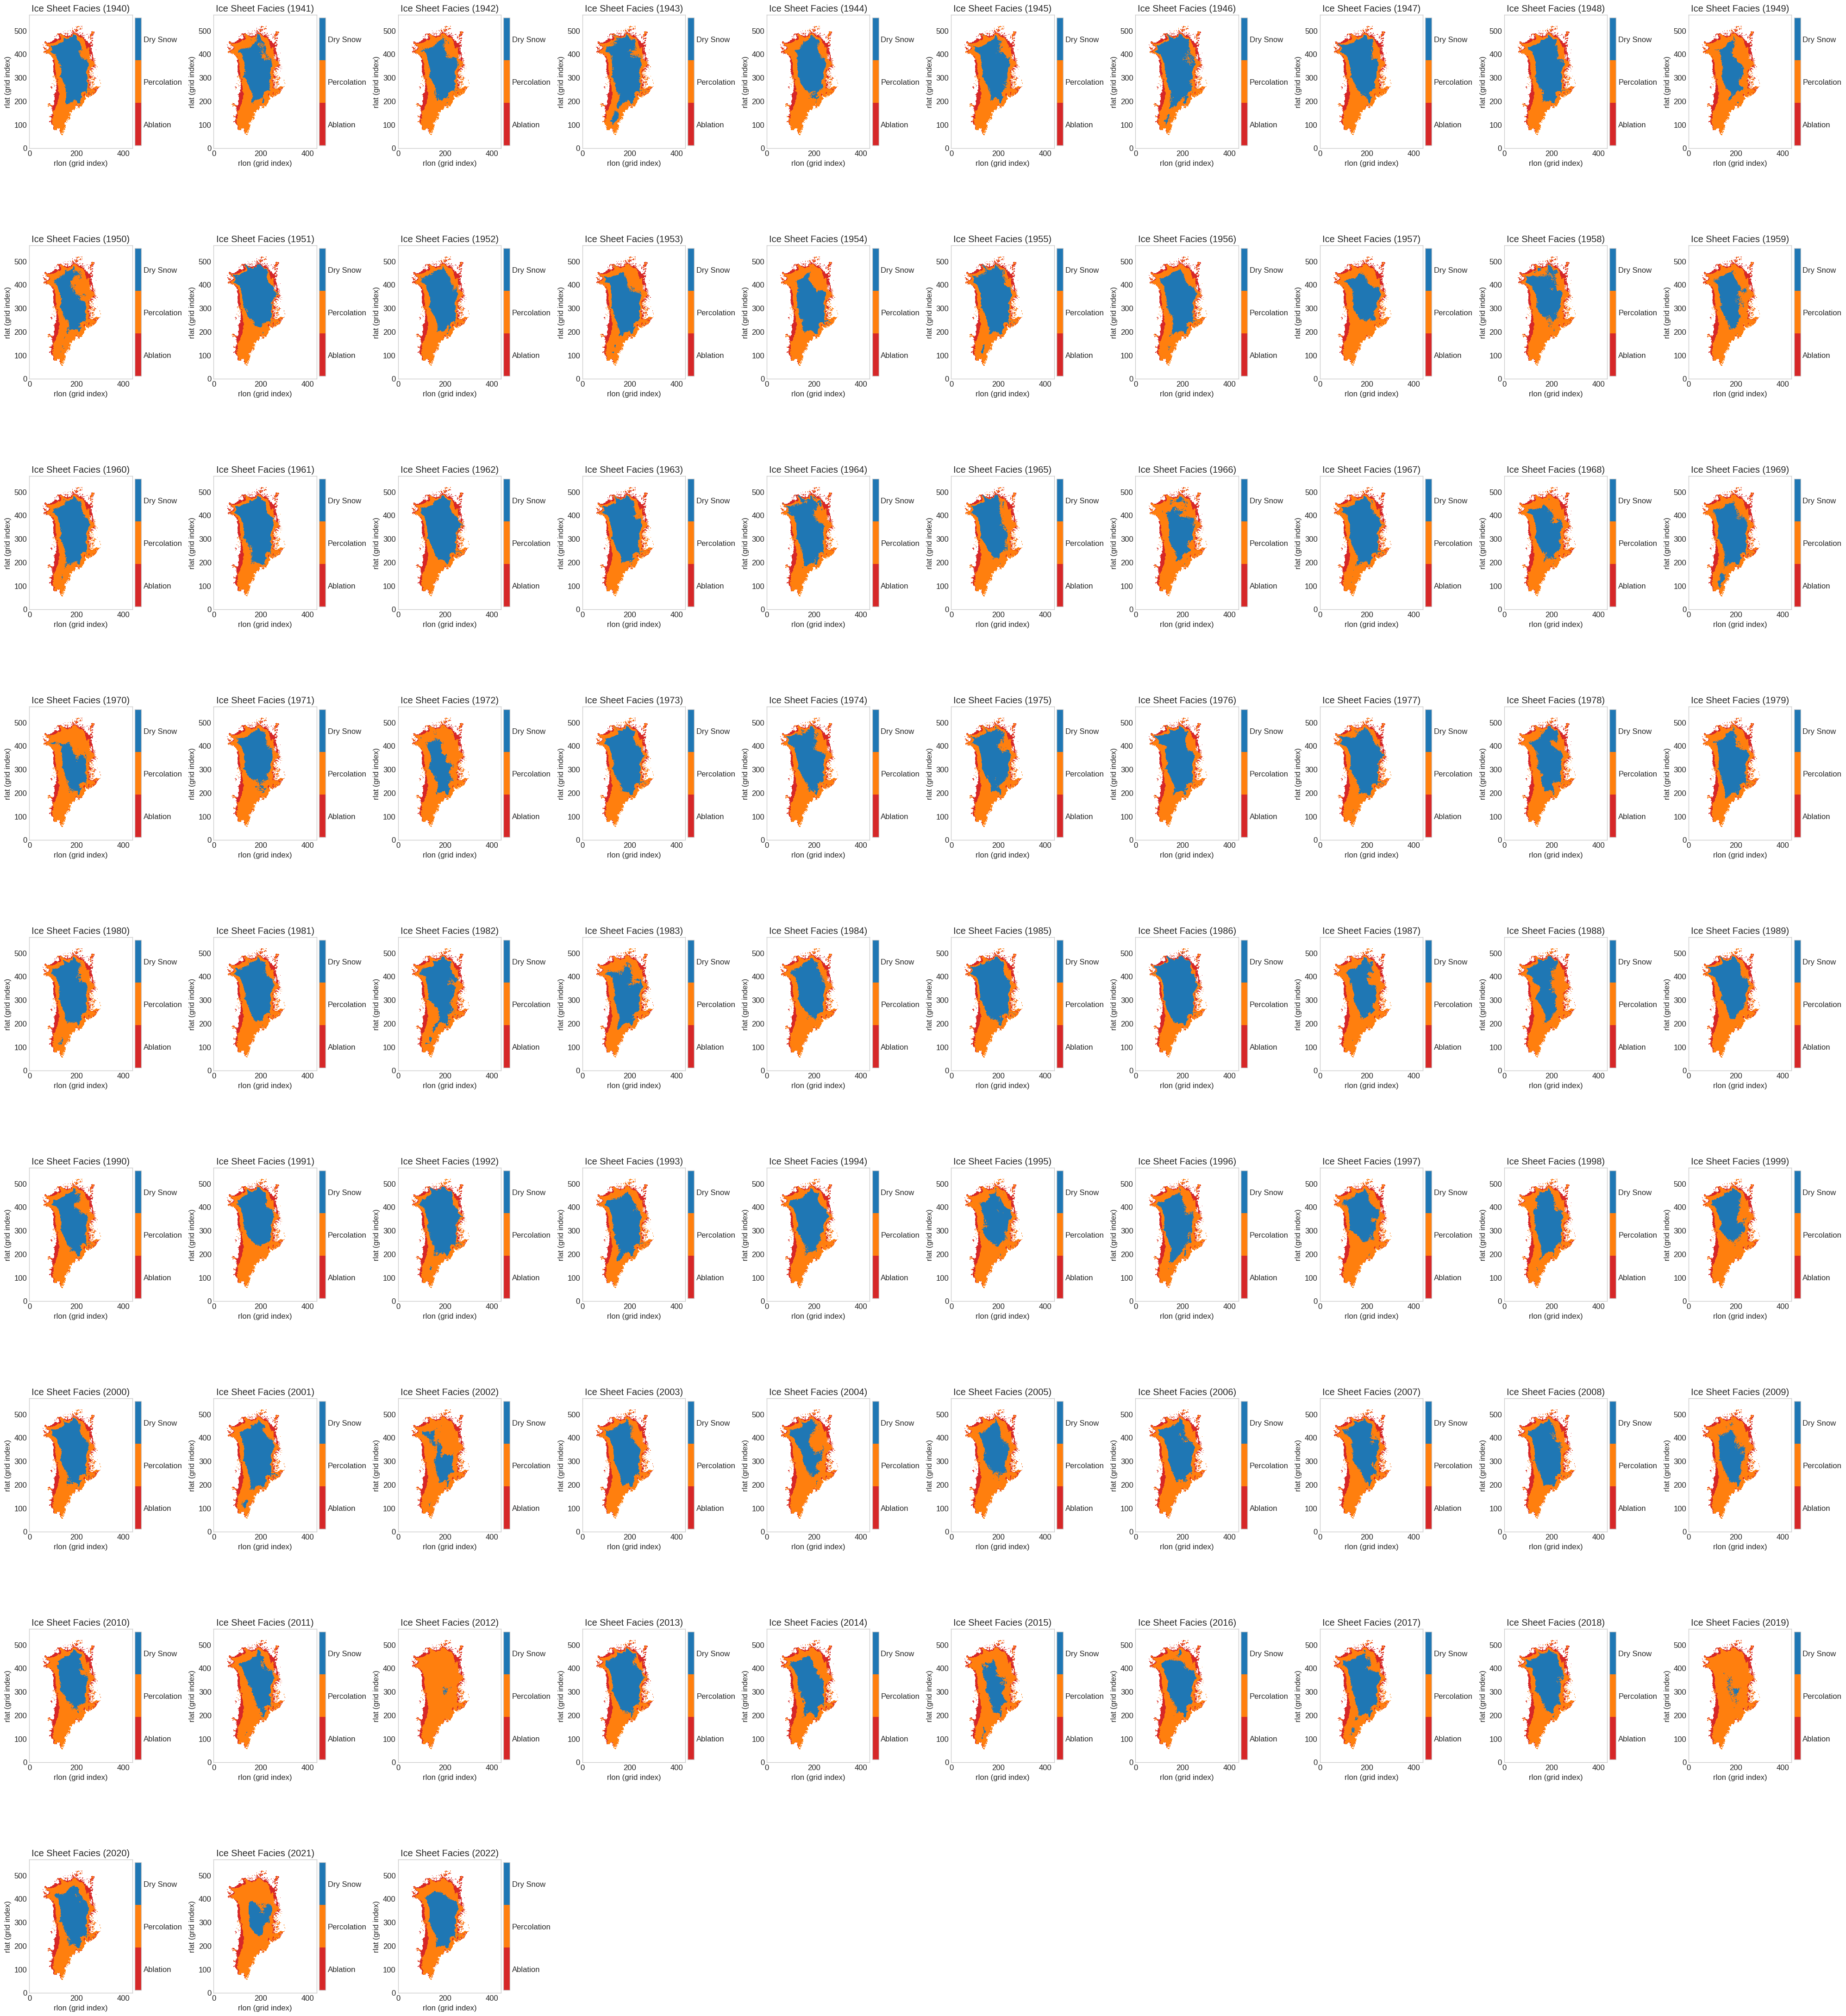

In [16]:
# Example 8: Plot zone evolution over multiple years
years = list(range(1940,2023,1))
plot_zones_timeseries(years, firn_air_threshold=0.5, melt_threshold=5.0, ncols=10)
plt.show()

## Animation / GIF Creation

Create animated GIFs showing how a variable evolves over time.

In [ ]:
# Example 9: Create an animated GIF of runoff for a single year
# create_animation_gif(
#     'Runoff',
#     'runoff_2019.gif',
#     time_slice=slice(2019, 2020),
#     cmap='Blues',
#     vmin=0,
#     vmax=500,
#     fps=5
# )

#Example 10: Create a longer animation spanning multiple years
create_animation_gif(
    'surfmelt',
    'surfmelt_2010-2020.gif',
    time_slice=slice(2010, 2020),
    cmap='Reds',
    vmin=0,
    vmax=100,
    fps=15
)

## Masked Difference Plotting

Compare two variables using masks to identify where one process occurs but another doesn't.
For example: where does surface melt occur but runoff doesn't (indicating refreezing)?

In [1]:
# Example 11: Where does melt occur but runoff doesn't? (indicates refreezing)
fig, ax, data = plot_masked_difference(
    'surfmelt', 'Runoff',
    time_slice=slice(2019, 2020),
    comparison='var1_only'
)
ax.set_title('Surface Melt without Runoff (2019)\n(Indicates refreezing)')
plt.show()

NameError: name 'plot_masked_difference' is not defined

In [ ]:
# Example 12: Difference between melt and runoff (positive = meltwater retained)
fig, ax, data = plot_masked_difference(
    'surfmelt', 'Runoff',
    time_slice=slice(2019, 2020),
    comparison='difference',
    cmap='RdBu_r'
)
plt.show()

In [ ]:
# Example 13: Full 2x2 comparison of melt/runoff processes
fig, axes = plot_process_comparison(time_slice=slice(2019, 2020))
plt.show()